# 1D Bayesian Neural Network for $f(x)=\sin(x)$ (Variational Inference / ELBO)

This notebook contains:
- a compact **math derivation** of the ELBO for variational Bayesian neural networks,
- a **PyTorch** implementation (mean-field Gaussian weights),
- a **visualization** of predictive mean and uncertainty band for $\sin(x)$.


## 1. Math derivation

Data: $\mathcal D=\{(x_i,y_i)\}_{i=1}^n$ with
$$
y_i=f(x_i)+\varepsilon_i,\qquad \varepsilon_i\sim\mathcal N(0,\sigma_\text{noise}^2).
$$
A neural net with weights $w$ defines $f_w(x)$.

### Likelihood
$$
p(y_i\mid x_i,w)=\mathcal N\big(y_i; f_w(x_i),\sigma_\text{noise}^2\big).
$$

### Prior
$$p(w)=\mathcal N(0,\sigma_0^2 I).$$

### Variational posterior (mean-field)
$$
q_\theta(w)=\prod_k \mathcal N(w_k;\mu_k,\sigma_k^2),\qquad \sigma_k=\mathrm{softplus}(\rho_k).
$$

### ELBO
Start from the marginal likelihood:
$$\log p(\mathcal D)=\log\int p(\mathcal D\mid w)p(w)\,dw.$$
Insert $q_\theta(w)$ and apply Jensen:
$$
\log p(\mathcal D)=\log\int q_\theta(w)\frac{p(\mathcal D\mid w)p(w)}{q_\theta(w)}dw
\ge \mathbb E_{q_\theta}[\log p(\mathcal D\mid w)]-\mathrm{KL}(q_\theta(w)\|p(w)).
$$
We **maximize** ELBO; equivalently **minimize** negative ELBO:
$$
\mathcal J(\theta)= -\mathbb E_{q_\theta}[\log p(\mathcal D\mid w)]+\mathrm{KL}(q_\theta(w)\|p(w)).
$$

### Gaussian regression NLL (up to a constant)
$$
-\log p(\mathcal D\mid w)=\sum_{i=1}^n \frac{(y_i-f_w(x_i))^2}{2\sigma_\text{noise}^2}+\text{const}.
$$

### Reparameterization
$$w=\mu+\sigma\odot\epsilon,\quad \epsilon\sim\mathcal N(0,I).$$

### Closed-form KL per coordinate
If $q=\mathcal N(\mu,\sigma^2)$ and $p=\mathcal N(0,\sigma_0^2)$,
$$
\mathrm{KL}(q\|p)=\tfrac12\left(\frac{\sigma^2+\mu^2}{\sigma_0^2}-1+\log\frac{\sigma_0^2}{\sigma^2}\right).
$$
Summing over all weights/biases gives the KL term used below.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)


## 2. Data: noisy samples from $\sin(x)$


In [9]:
n = 200
noise_sigma = 0.1

x_train = (torch.rand(n, 1) * 8.0) - 4.0   # [-3, 3]
y_train = torch.sin(x_train) + noise_sigma * torch.randn_like(x_train)

x_grid = torch.linspace(-4.5, 4.5, 400).unsqueeze(1)
y_true = torch.sin(x_grid)

x_train.shape, y_train.shape


(torch.Size([200, 1]), torch.Size([200, 1]))

## 3. Bayesian layers (mean-field Gaussian)


In [10]:
class BayesLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.prior_sigma = float(prior_sigma)
        self.w_mu  = nn.Parameter(torch.empty(out_features, in_features).normal_(0, 0.1))
        self.w_rho = nn.Parameter(torch.empty(out_features, in_features).normal_(-3, 0.1))
        self.b_mu  = nn.Parameter(torch.empty(out_features).normal_(0, 0.1))
        self.b_rho = nn.Parameter(torch.empty(out_features).normal_(-3, 0.1))

    @staticmethod
    def softplus(x):
        return torch.log1p(torch.exp(x))

    def _sample(self, mu, rho):
        sigma = self.softplus(rho)
        eps = torch.randn_like(mu)
        return mu + sigma * eps, sigma

    def forward(self, x):
        w, w_sigma = self._sample(self.w_mu, self.w_rho)
        b, b_sigma = self._sample(self.b_mu, self.b_rho)
        out = F.linear(x, w, b)

        prior_var = self.prior_sigma ** 2
        kl_w = 0.5 * torch.sum((w_sigma**2 + self.w_mu**2) / prior_var - 1.0
                               + torch.log(prior_var / (w_sigma**2 + 1e-12)))
        kl_b = 0.5 * torch.sum((b_sigma**2 + self.b_mu**2) / prior_var - 1.0
                               + torch.log(prior_var / (b_sigma**2 + 1e-12)))
        return out, (kl_w + kl_b)


## 4. Bayesian MLP + negative ELBO loss


In [11]:
class BayesianMLP(nn.Module):
    def __init__(self, d_in=1, hidden=(64, 64), d_out=1, prior_sigma=1.0, activation='tanh'):
        super().__init__()
        dims = (d_in,) + tuple(hidden) + (d_out,)
        self.layers = nn.ModuleList([
            BayesLinear(dims[i], dims[i+1], prior_sigma=prior_sigma)
            for i in range(len(dims)-1)
        ])
        self.activation = activation

    def _act(self, x):
        if self.activation == 'relu':
            return F.relu(x)
        if self.activation == 'tanh':
            return torch.tanh(x)
        if self.activation == 'gelu':
            return F.gelu(x)
        raise ValueError('activation must be relu/tanh/gelu')

    def forward(self, x):
        total_kl = 0.0
        for i, layer in enumerate(self.layers):
            x, kl = layer(x)
            total_kl = total_kl + kl
            if i < len(self.layers) - 1:
                x = self._act(x)
        return x, total_kl


def neg_elbo(model, x, y, noise_sigma=0.15, mc_samples=3):
    """Negative ELBO = E_q[NLL] + KL. Gaussian likelihood N(y; f_w(x), noise_sigma^2)."""
    n = x.shape[0]
    nll = 0.0
    kl = 0.0
    for _ in range(mc_samples):
        pred, kl_s = model(x)
        nll = nll + 0.5 * torch.sum((y - pred)**2) / (noise_sigma**2)
        kl = kl + kl_s
    nll = nll / mc_samples
    kl = kl / mc_samples
    return (nll + kl) / n, (nll / n).item(), (kl / n).item()


## 5. Train


In [12]:
model = BayesianMLP(hidden=(20, 20, 20), prior_sigma=1.0, activation='tanh')
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    opt.zero_grad()
    loss, nll_per, kl_per = neg_elbo(model, x_train, y_train, noise_sigma=noise_sigma, mc_samples=3)
    loss.backward()
    opt.step()
    if (epoch + 1) % 400 == 0:
        print(f"epoch {epoch+1:4d} | negELBO {loss.item():.4f} | NLL {nll_per:.4f} | KL {kl_per:.4f}")


epoch  400 | negELBO 16.2630 | NLL 5.6785 | KL 10.5845
epoch  800 | negELBO 12.6643 | NLL 2.3095 | KL 10.3549
epoch 1200 | negELBO 14.0521 | NLL 3.8866 | KL 10.1654
epoch 1600 | negELBO 12.0595 | NLL 2.0861 | KL 9.9735
epoch 2000 | negELBO 11.3455 | NLL 1.5766 | KL 9.7689


## 6. Predictive mean + uncertainty band


In [13]:
@torch.no_grad()
def predict_with_uncertainty(model, x, mc_samples=300):
    preds = []
    for _ in range(mc_samples):
        p, _ = model(x)
        preds.append(p)
    preds = torch.stack(preds, dim=0)
    return preds.mean(dim=0), preds.std(dim=0)

mean, std = predict_with_uncertainty(model, x_grid, mc_samples=400)
mean = mean.squeeze().cpu()
std = std.squeeze().cpu()


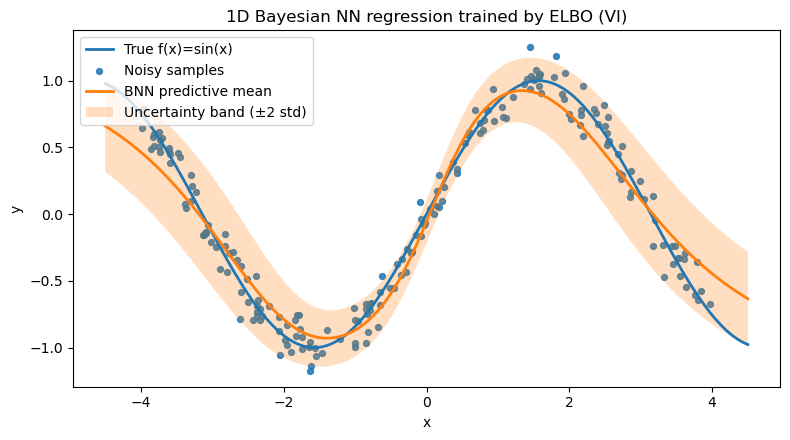

In [14]:
plt.figure(figsize=(8, 4.5))
plt.plot(x_grid.squeeze().cpu(), y_true.squeeze().cpu(), linewidth=2, label='True f(x)=sin(x)')
plt.scatter(x_train.squeeze().cpu(), y_train.squeeze().cpu(), s=18, alpha=0.85, label='Noisy samples')
plt.plot(x_grid.squeeze().cpu(), mean, linewidth=2, label='BNN predictive mean')
plt.fill_between(x_grid.squeeze().cpu(), mean - 2*std, mean + 2*std, alpha=0.25, label='Uncertainty band (±2 std)')
plt.title('1D Bayesian NN regression trained by ELBO (VI)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Code summary

- `BayesLinear`: keeps $(\mu,\rho)$, samples weights, returns forward output + KL.
- `neg_elbo`: Monte Carlo estimate of **negative ELBO** = NLL + KL.
- predictive band: sample weights many times to estimate mean/std.
